# AVAX-USD — Turtle System 1 Deep Dive

AVAX stood out in the multi-frequency sweep: 8h Sharpe 0.83 with 42% drawdown compression
on an asset where B&H Sharpe is essentially zero (-36.5% CAGR). This notebook dissects
the trade-level mechanics to understand *why* the system works here.

In [1]:
from _setup import *

[setup] Project: trend_crypto  |  DuckDB: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/market.duckdb
[setup] Ready — np, pd, plt, load_daily_bars, simple_backtest, compute_metrics, ...


## 1. Configuration

In [3]:
SYMBOL = "AVAX-USD"
ENTRY_PERIOD = 20
EXIT_PERIOD = 10
COST_BPS = 20.0

FREQS = ["8h", "1d"]
BARS_PER_YEAR = {"8h": 3 * 365, "1d": 365}

## 2. Load data at both frequencies

In [4]:
data = {}
for freq in FREQS:
    panel = load_bars(freq)
    df = panel[panel["symbol"] == SYMBOL].copy().sort_values("ts").set_index("ts")
    data[freq] = df
    print(f"{freq}: {len(df)} bars, {df.index.min()} to {df.index.max()}")

[data] Loading cached 8h bars from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_8h_2017-01-01_2026-12-31.parquet
8h: 4792 bars, 2021-09-30 16:00:00 to 2026-02-13 16:00:00
[data] Loading cached daily bars from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_1d_2017-01-01_2026-12-31.parquet
1d: 1598 bars, 2021-09-30 00:00:00 to 2026-02-13 00:00:00


## 3. Signal generation + backtest engine

In [5]:
def compute_atr(high, low, close, period=20):
    prev_close = close.shift(1)
    tr = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)
    return tr.rolling(period, min_periods=period).mean()


def turtle_sys1(close, high, low, entry_period, exit_period):
    """Binary System 1 signal: long on breakout, flat on channel exit."""
    entry_high = high.shift(1).rolling(entry_period, min_periods=entry_period).max()
    exit_low = low.shift(1).rolling(exit_period, min_periods=exit_period).min()
    signal = pd.Series(np.nan, index=close.index)
    signal[close > entry_high] = 1.0
    signal[close < exit_low] = 0.0
    return signal.ffill().fillna(0.0), entry_high, exit_low


def run_core_backtest(signal, close, symbol, cost_bps=COST_BPS):
    """Wrap single-asset signal into the core simple_backtest framework."""
    ret = close.pct_change(fill_method=None).fillna(0.0)

    weights = pd.DataFrame({symbol: signal}, index=close.index)
    returns = pd.DataFrame({symbol: ret}, index=close.index)
    bh_weights = pd.DataFrame({symbol: 1.0}, index=close.index)

    bt = simple_backtest(weights, returns, cost_bps=cost_bps)
    bt_bh = simple_backtest(bh_weights, returns, cost_bps=0.0)

    eq = bt.set_index("ts")["portfolio_equity"]
    bh_eq = bt_bh.set_index("ts")["portfolio_equity"]
    strat_ret = bt.set_index("ts")["portfolio_ret"]

    return strat_ret, eq, bh_eq

## 4. Run both frequencies

In [6]:
results = {}

for freq in FREQS:
    df = data[freq]
    close, high, low = df["close"], df["high"], df["low"]
    atr = compute_atr(high, low, close, ENTRY_PERIOD)

    signal, entry_hi, exit_lo = turtle_sys1(close, high, low, ENTRY_PERIOD, EXIT_PERIOD)
    strat_ret, eq, bh_eq = run_core_backtest(signal, close, SYMBOL, COST_BPS)

    m_strat = compute_metrics(eq)
    m_bh = compute_metrics(bh_eq)

    results[freq] = {
        "signal": signal, "entry_hi": entry_hi, "exit_lo": exit_lo,
        "strat_ret": strat_ret, "eq": eq, "bh_eq": bh_eq,
        "atr": atr, "metrics": m_strat, "bh_metrics": m_bh,
    }

    tim = signal.mean()
    n_trades = (signal.diff().abs() > 0.5).sum()
    print(f"\n{freq.upper()}:")
    print(f"  Sharpe:  {m_strat['sharpe']:.2f}  (B&H: {m_bh['sharpe']:.2f})")
    print(f"  CAGR:    {m_strat['cagr']:.1%}  (B&H: {m_bh['cagr']:.1%})")
    print(f"  Max DD:  {m_strat['max_dd']:.1%}  (B&H: {m_bh['max_dd']:.1%})")
    print(f"  Skew:    {m_strat['skewness']:.2f}")
    print(f"  TIM:     {tim:.1%}")
    print(f"  Trades:  {n_trades}")


8H:
  Sharpe:  0.48  (B&H: 0.02)
  CAGR:    11.2%  (B&H: -14.1%)
  Max DD:  -51.5%  (B&H: -94.0%)
  Skew:    1.87
  TIM:     33.8%
  Trades:  112

1D:
  Sharpe:  0.50  (B&H: 0.02)
  CAGR:    12.8%  (B&H: -36.5%)
  Max DD:  -71.8%  (B&H: -93.9%)
  Skew:    0.80
  TIM:     30.8%
  Trades:  40


## 5. Equity curves

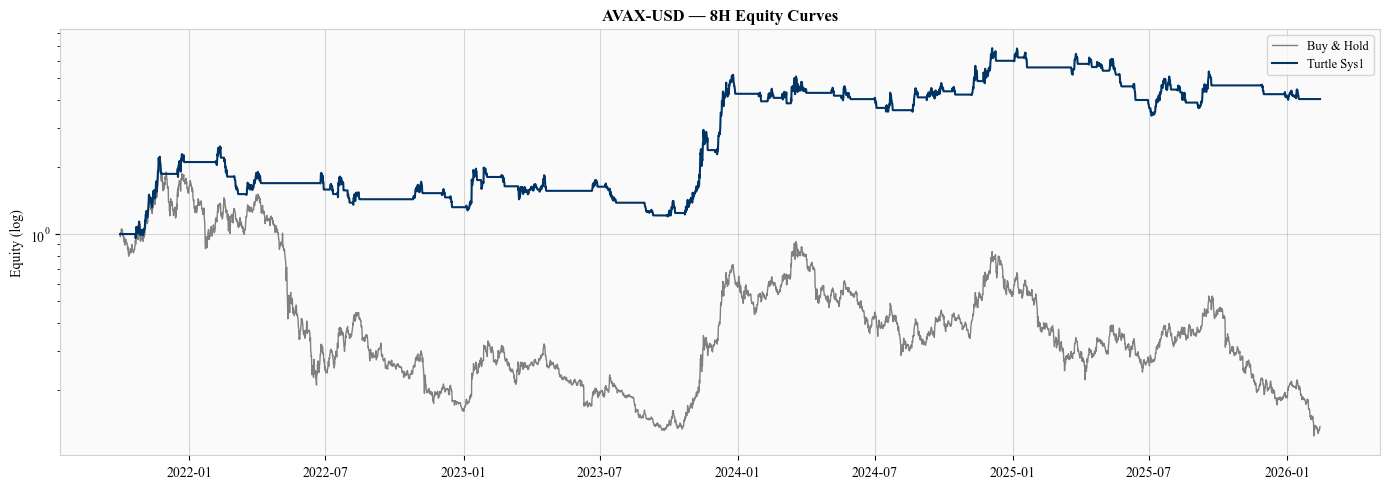

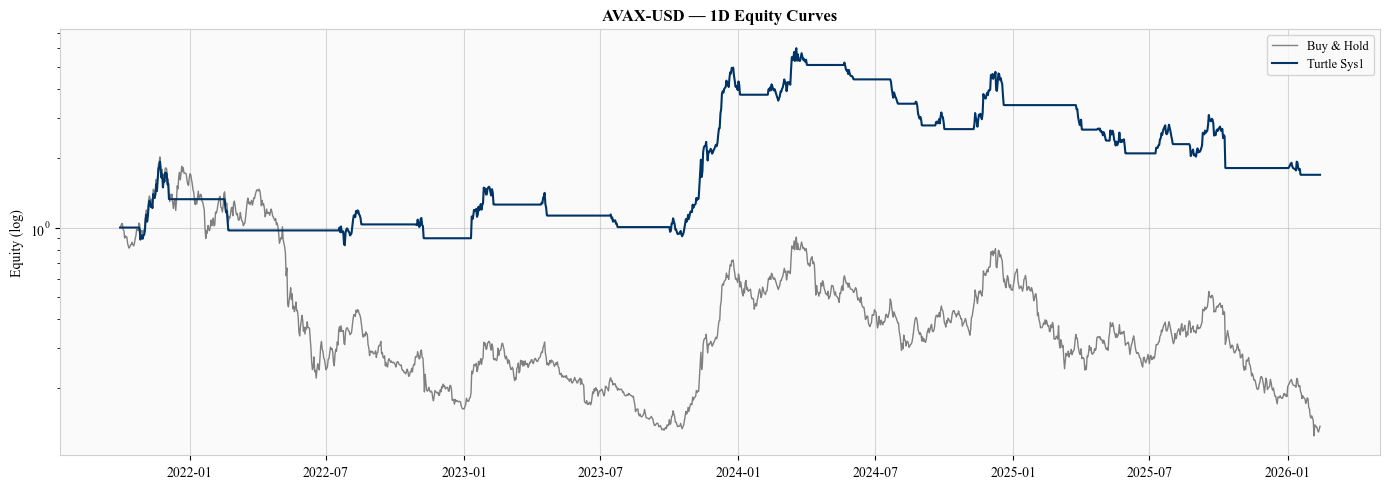

In [7]:
for freq in FREQS:
    r = results[freq]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(r["bh_eq"].index, r["bh_eq"].values, color=GRAY, lw=1.0, label="Buy & Hold")
    ax.plot(r["eq"].index, r["eq"].values, color=NAVY, lw=1.5, label="Turtle Sys1")
    ax.set_yscale("log")
    ax.set_title(f"{SYMBOL} — {freq.upper()} Equity Curves", fontweight="bold", fontsize=12)
    ax.set_ylabel("Equity (log)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

## 6. Drawdowns

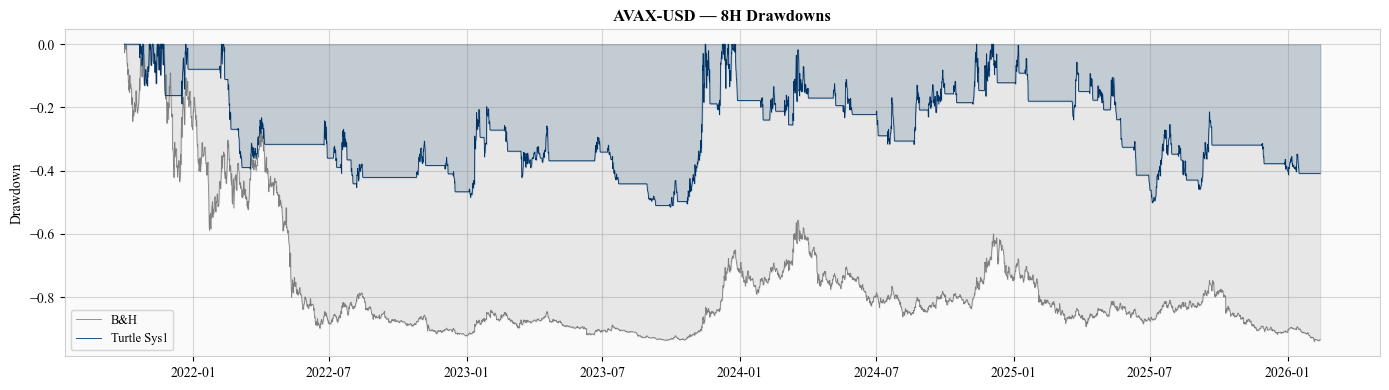

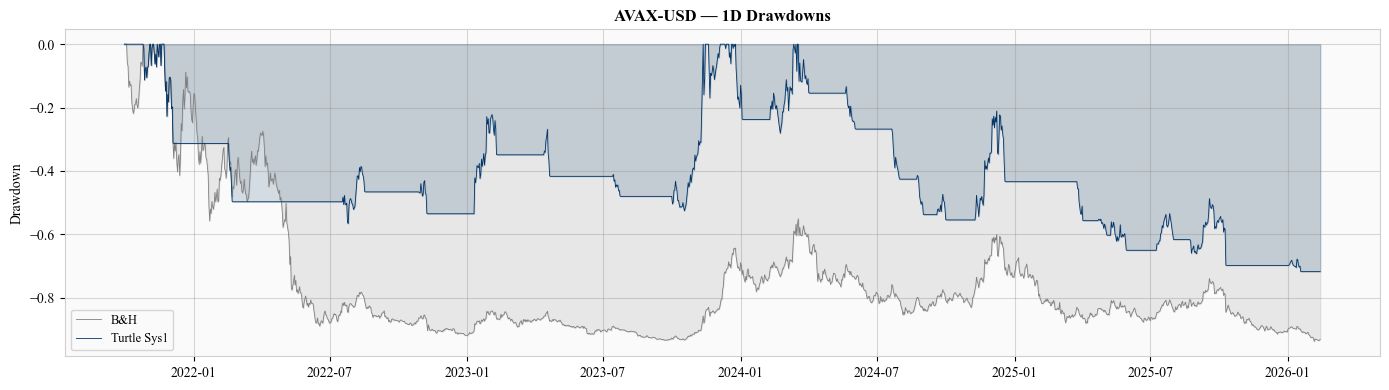

In [8]:
for freq in FREQS:
    r = results[freq]
    dd_strat = r["eq"] / r["eq"].cummax() - 1.0
    dd_bh = r["bh_eq"] / r["bh_eq"].cummax() - 1.0

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.fill_between(dd_bh.index, dd_bh.values, 0, alpha=0.15, color=GRAY)
    ax.plot(dd_bh.index, dd_bh.values, color=GRAY, lw=0.6, label="B&H")
    ax.fill_between(dd_strat.index, dd_strat.values, 0, alpha=0.15, color=NAVY)
    ax.plot(dd_strat.index, dd_strat.values, color=NAVY, lw=0.6, label="Turtle Sys1")
    ax.set_title(f"{SYMBOL} — {freq.upper()} Drawdowns", fontweight="bold", fontsize=12)
    ax.set_ylabel("Drawdown")
    ax.legend(fontsize=9, loc="lower left")
    fig.tight_layout()
    plt.show()

## 7. Signal + price overlay with breakout channels

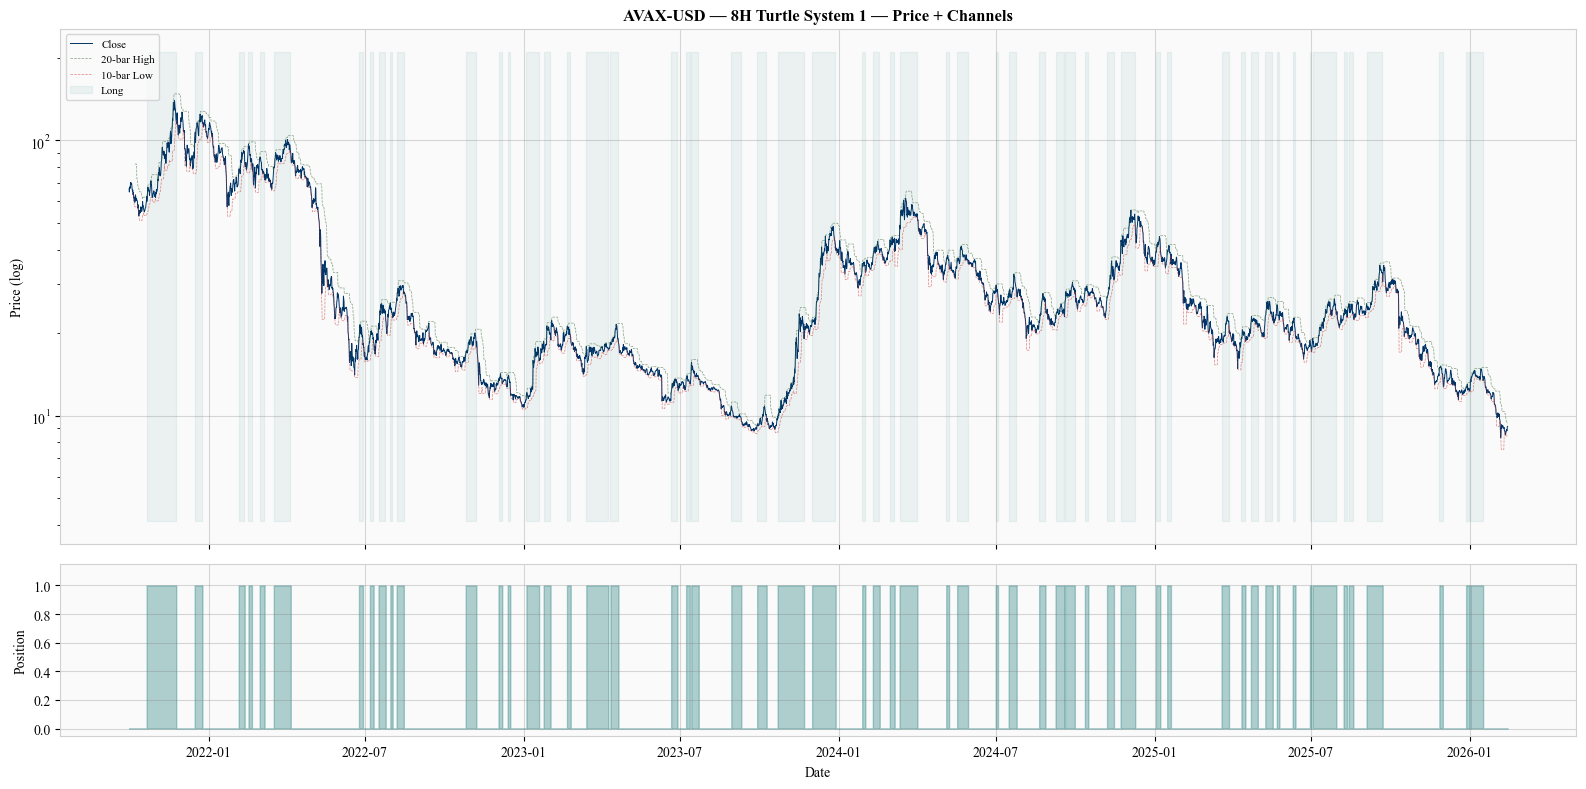

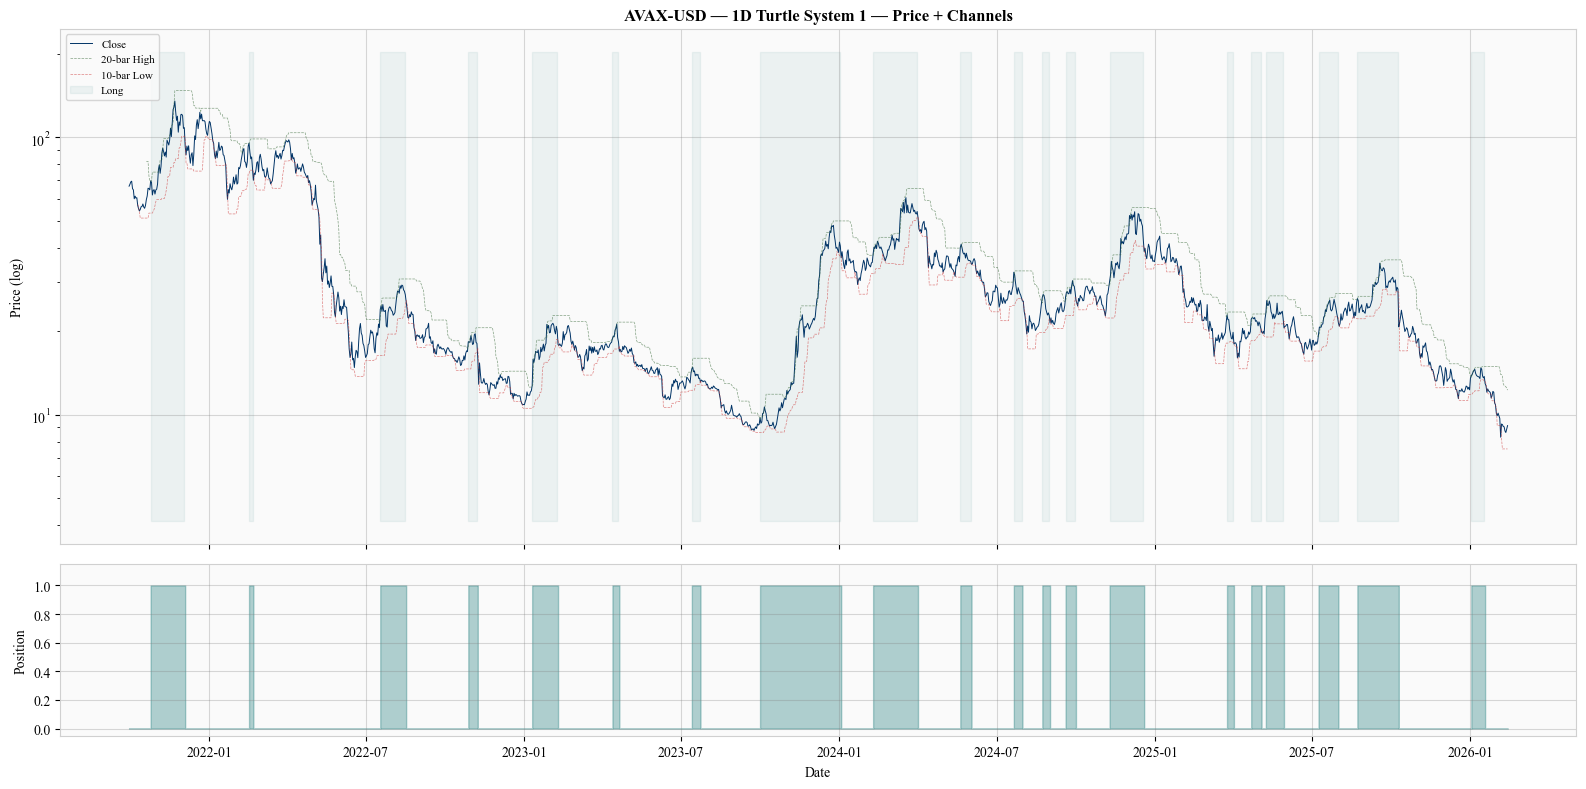

In [9]:
for freq in FREQS:
    r = results[freq]
    df = data[freq]
    close = df["close"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(close.index, close.values, color=NAVY, lw=0.7, label="Close")
    ax1.plot(r["entry_hi"].index, r["entry_hi"].values, color=GREEN, lw=0.5, ls="--",
             alpha=0.6, label=f"{ENTRY_PERIOD}-bar High")
    ax1.plot(r["exit_lo"].index, r["exit_lo"].values, color=RED, lw=0.5, ls="--",
             alpha=0.6, label=f"{EXIT_PERIOD}-bar Low")

    # Shade long periods
    sig = r["signal"]
    long_mask = sig > 0.5
    ax1.fill_between(close.index, close.min() * 0.5, close.max() * 1.5,
                     where=long_mask, alpha=0.06, color=TEAL, label="Long")

    ax1.set_yscale("log")
    ax1.set_ylabel("Price (log)")
    ax1.set_title(f"{SYMBOL} — {freq.upper()} Turtle System 1 — Price + Channels",
                  fontweight="bold", fontsize=12)
    ax1.legend(fontsize=8, loc="upper left")

    ax2.fill_between(sig.index, sig.values, alpha=0.3, color=TEAL, step="post")
    ax2.set_ylabel("Position")
    ax2.set_ylim(-0.05, 1.15)
    ax2.set_xlabel("Date")

    fig.tight_layout()
    plt.show()

## 8. Trade log

Extract every entry/exit, compute per-trade P&L, duration, and max adverse excursion.

In [10]:
def extract_trades(signal, close, freq_label):
    """Build a trade log from a binary signal."""
    sig = signal.copy()
    transitions = sig.diff().fillna(0)
    entries = transitions[transitions > 0.5].index
    exits = transitions[transitions < -0.5].index

    trades = []
    for entry_ts in entries:
        # Find next exit after this entry
        future_exits = exits[exits > entry_ts]
        if len(future_exits) == 0:
            exit_ts = close.index[-1]  # still open
            still_open = True
        else:
            exit_ts = future_exits[0]
            still_open = False

        entry_price = close.loc[entry_ts]
        exit_price = close.loc[exit_ts]
        trade_close = close.loc[entry_ts:exit_ts]
        peak = trade_close.max()
        trough = trade_close.min()

        pnl_pct = (exit_price / entry_price) - 1.0
        mae = (trough / entry_price) - 1.0  # max adverse excursion
        mfe = (peak / entry_price) - 1.0    # max favorable excursion
        duration_bars = len(trade_close) - 1

        trades.append({
            "entry_ts": entry_ts, "exit_ts": exit_ts,
            "entry_price": entry_price, "exit_price": exit_price,
            "pnl_pct": pnl_pct, "mae": mae, "mfe": mfe,
            "duration_bars": duration_bars, "still_open": still_open,
        })

    return pd.DataFrame(trades)


for freq in FREQS:
    tlog = extract_trades(results[freq]["signal"], data[freq]["close"], freq)
    n = len(tlog)
    winners = (tlog["pnl_pct"] > 0).sum()
    losers = (tlog["pnl_pct"] <= 0).sum()

    print(f"\n{'='*60}")
    print(f"  {freq.upper()} — {n} trades (Win: {winners}, Loss: {losers}, Win%: {winners/n:.1%})")
    print(f"{'='*60}")
    print(f"  Avg P&L:   {tlog['pnl_pct'].mean():+.1%}")
    print(f"  Med P&L:   {tlog['pnl_pct'].median():+.1%}")
    print(f"  Best:      {tlog['pnl_pct'].max():+.1%}")
    print(f"  Worst:     {tlog['pnl_pct'].min():+.1%}")
    print(f"  Avg MAE:   {tlog['mae'].mean():.1%}")
    print(f"  Avg MFE:   {tlog['mfe'].mean():.1%}")
    print(f"  Avg duration: {tlog['duration_bars'].mean():.0f} bars")
    print()
    display(tlog.round(3))


  8H — 56 trades (Win: 23, Loss: 33, Win%: 41.1%)
  Avg P&L:   +4.7%
  Med P&L:   -2.5%
  Best:      +92.2%
  Worst:     -17.4%
  Avg MAE:   -5.1%
  Avg MFE:   18.2%
  Avg duration: 29 bars



,entry_ts,exit_ts,entry_price,exit_price,pnl_pct,mae,mfe,duration_bars,still_open
0,2021-10-21 00:00:00,2021-11-24 08:00:00,62.56,116.95,0.869,-0.041,1.228,103,False
1,2021-12-15 16:00:00,2021-12-24 16:00:00,101.30,114.93,0.135,-0.030,0.230,27,False
2,2022-02-04 16:00:00,2022-02-11 16:00:00,77.91,81.81,0.050,-0.029,0.179,21,False
3,2022-02-16 00:00:00,2022-02-20 00:00:00,97.06,80.15,-0.174,-0.174,0.000,12,False
4,2022-03-01 00:00:00,2022-03-06 16:00:00,86.46,72.47,-0.162,-0.162,0.006,17,False
5,2022-03-17 08:00:00,2022-04-06 00:00:00,79.98,89.93,0.124,-0.006,0.260,59,False
6,2022-06-24 00:00:00,2022-06-28 16:00:00,19.24,18.08,-0.060,-0.060,0.111,14,False
7,2022-07-06 16:00:00,2022-07-11 00:00:00,19.15,18.35,-0.042,-0.042,0.062,13,False
8,2022-07-16 16:00:00,2022-07-25 00:00:00,21.24,22.15,0.043,-0.029,0.200,25,False
9,2022-07-30 08:00:00,2022-08-02 00:00:00,25.67,22.70,-0.116,-0.116,0.000,8,False



  1D — 20 trades (Win: 7, Loss: 13, Win%: 35.0%)
  Avg P&L:   +12.2%
  Med P&L:   -10.1%
  Best:      +277.5%
  Worst:     -26.5%
  Avg MAE:   -11.3%
  Avg MFE:   42.1%
  Avg duration: 25 bars



,entry_ts,exit_ts,entry_price,exit_price,pnl_pct,mae,mfe,duration_bars,still_open
0,2021-10-25,2021-12-04,69.80,93.08,0.334,-0.111,0.938,40,False
1,2022-02-16,2022-02-21,95.39,70.08,-0.265,-0.265,0.000,5,False
2,2022-07-18,2022-08-17,23.97,25.56,0.066,-0.136,0.224,30,False
3,2022-10-28,2022-11-08,18.34,16.03,-0.126,-0.126,0.069,11,False
4,2023-01-10,2023-02-09,12.74,17.91,0.406,0.000,0.677,30,False
5,2023-04-13,2023-04-21,18.84,16.94,-0.101,-0.101,0.126,8,False
6,2023-07-14,2023-07-24,14.65,13.11,-0.105,-0.105,0.013,10,False
7,2023-10-01,2024-01-03,9.75,36.81,2.775,-0.086,3.944,94,False
8,2024-02-09,2024-04-01,38.02,51.40,0.352,-0.055,0.596,52,False
9,2024-05-20,2024-06-02,40.13,34.88,-0.131,-0.131,0.027,13,False


## 9. Trade P&L distribution

In [ ]:
for freq in FREQS:
    tlog = extract_trades(results[freq]["signal"], data[freq]["close"], freq)
    pnl = tlog["pnl_pct"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # P&L histogram
    ax = axes[0]
    colors_pnl = [GREEN if p > 0 else RED for p in pnl]
    ax.bar(range(len(pnl)), pnl.values, color=colors_pnl, alpha=0.7)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"{freq.upper()} — Per-Trade P&L", fontweight="bold")
    ax.set_ylabel("Return")
    ax.set_xlabel("Trade #")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    # MAE vs MFE scatter
    ax = axes[1]
    win_mask = tlog["pnl_pct"] > 0
    ax.scatter(tlog.loc[win_mask, "mae"], tlog.loc[win_mask, "mfe"],
              color=GREEN, alpha=0.6, s=30, label="Winner")
    ax.scatter(tlog.loc[~win_mask, "mae"], tlog.loc[~win_mask, "mfe"],
              color=RED, alpha=0.6, s=30, label="Loser")
    ax.set_title(f"{freq.upper()} — MAE vs MFE", fontweight="bold")
    ax.set_xlabel("Max Adverse Excursion")
    ax.set_ylabel("Max Favorable Excursion")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    # Duration vs P&L
    ax = axes[2]
    ax.scatter(tlog["duration_bars"], tlog["pnl_pct"],
              color=[GREEN if p > 0 else RED for p in tlog["pnl_pct"]],
              alpha=0.6, s=30)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"{freq.upper()} — Duration vs P&L", fontweight="bold")
    ax.set_xlabel("Duration (bars)")
    ax.set_ylabel("Trade Return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    fig.tight_layout()
    plt.show()

## 10. Rolling performance

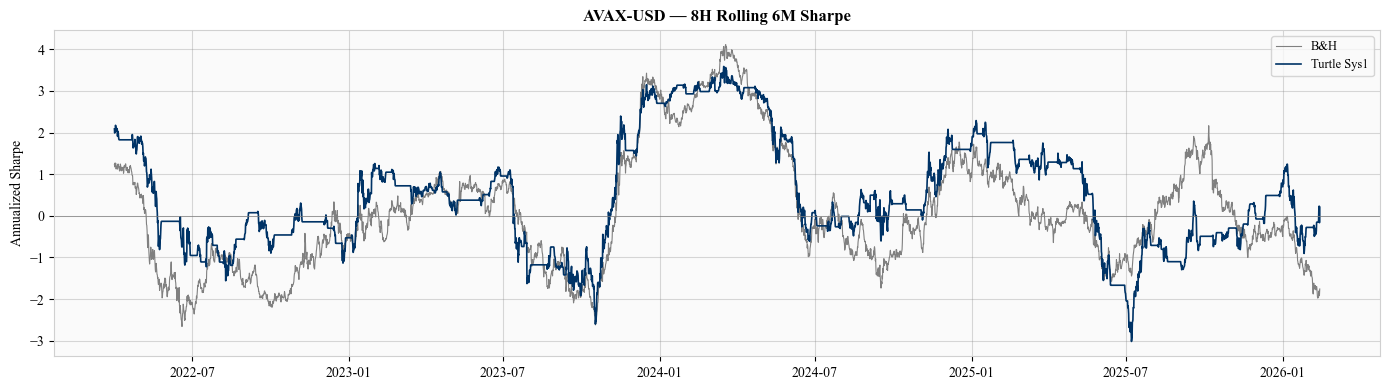

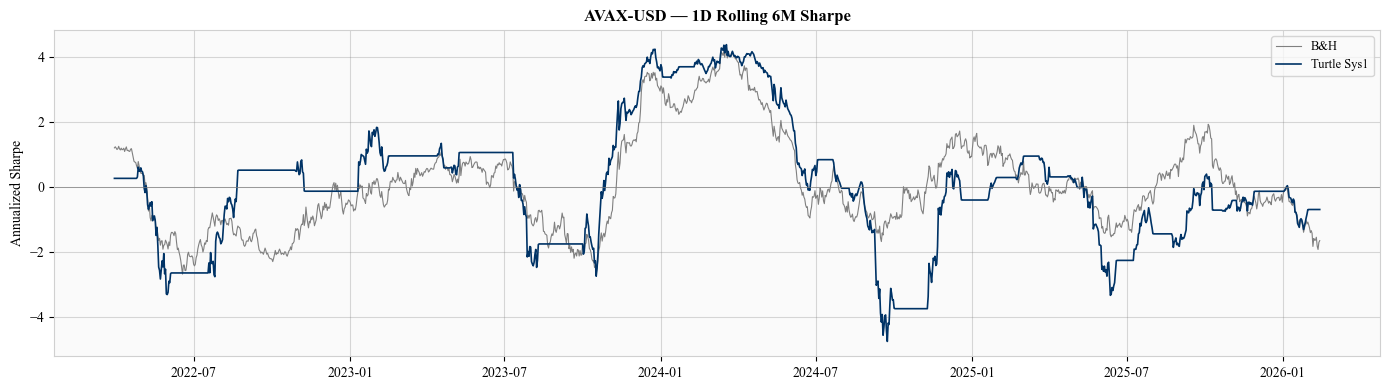

In [11]:
for freq in FREQS:
    r = results[freq]
    bpy = BARS_PER_YEAR[freq]
    window = int(bpy * 0.5)  # 6-month rolling window

    strat_roll = r["strat_ret"].rolling(window)
    bh_ret = data[freq]["close"].pct_change(fill_method=None).fillna(0.0)
    bh_roll = bh_ret.rolling(window)

    roll_sharpe_strat = strat_roll.mean() / strat_roll.std() * np.sqrt(bpy)
    roll_sharpe_bh = bh_roll.mean() / bh_roll.std() * np.sqrt(bpy)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(roll_sharpe_bh.index, roll_sharpe_bh.values, color=GRAY, lw=0.8, label="B&H")
    ax.plot(roll_sharpe_strat.index, roll_sharpe_strat.values, color=NAVY, lw=1.2, label="Turtle Sys1")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(f"{SYMBOL} — {freq.upper()} Rolling 6M Sharpe", fontweight="bold")
    ax.set_ylabel("Annualized Sharpe")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

## 11. Cumulative P&L attribution: when is the system adding value?

Plot the difference between Turtle equity and B&H equity over time to see exactly
which periods drive the strategy's outperformance.

In [ ]:
for freq in FREQS:
    r = results[freq]
    close = data[freq]["close"]
    bh_ret = close.pct_change(fill_method=None).fillna(0.0)
    excess = r["strat_ret"] - bh_ret
    cum_excess = excess.cumsum()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

    # Price with long/flat shading
    ax1.plot(close.index, close.values, color=NAVY, lw=0.7)
    sig = r["signal"]
    long_mask = sig > 0.5
    ax1.fill_between(close.index, close.min() * 0.5, close.max() * 1.5,
                     where=long_mask, alpha=0.06, color=TEAL, label="Long")
    ax1.fill_between(close.index, close.min() * 0.5, close.max() * 1.5,
                     where=~long_mask, alpha=0.06, color=RED, label="Cash")
    ax1.set_yscale("log")
    ax1.set_ylabel("Price")
    ax1.set_title(f"{SYMBOL} — {freq.upper()} Cumulative Excess Return vs B&H", fontweight="bold")
    ax1.legend(fontsize=8, loc="upper left")

    # Cumulative excess
    ax2.plot(cum_excess.index, cum_excess.values, color=TEAL, lw=1.2)
    ax2.fill_between(cum_excess.index, cum_excess.values, 0,
                     where=cum_excess.values >= 0, alpha=0.15, color=GREEN)
    ax2.fill_between(cum_excess.index, cum_excess.values, 0,
                     where=cum_excess.values < 0, alpha=0.15, color=RED)
    ax2.axhline(0, color="gray", lw=0.5)
    ax2.set_ylabel("Cumulative Excess Return")
    ax2.set_xlabel("Date")

    fig.tight_layout()
    plt.show()

## 12. ATR and volatility context

In [ ]:
for freq in FREQS:
    df = data[freq]
    close = df["close"]
    atr = results[freq]["atr"]
    atr_pct = atr / close  # ATR as % of price

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

    ax1.plot(close.index, close.values, color=NAVY, lw=0.7)
    ax1.set_yscale("log")
    ax1.set_ylabel("Price")
    ax1.set_title(f"{SYMBOL} — {freq.upper()} Price + ATR Volatility", fontweight="bold")

    ax2.plot(atr_pct.index, atr_pct.values, color=GOLD, lw=0.7)
    ax2.set_ylabel("ATR / Price")
    ax2.set_xlabel("Date")
    ax2.axhline(atr_pct.median(), color=RED, ls="--", lw=0.8,
                label=f"Median: {atr_pct.median():.1%}")
    ax2.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

## 13. Summary comparison table

In [ ]:
rows = []
for freq in FREQS:
    r = results[freq]
    m = r["metrics"]
    bm = r["bh_metrics"]
    sig = r["signal"]
    rows.append({
        "Frequency": freq.upper(),
        "Sharpe": f"{m['sharpe']:.2f}",
        "B&H Sharpe": f"{bm['sharpe']:.2f}",
        "CAGR": f"{m['cagr']:.1%}",
        "B&H CAGR": f"{bm['cagr']:.1%}",
        "Max DD": f"{m['max_dd']:.1%}",
        "B&H Max DD": f"{bm['max_dd']:.1%}",
        "DD Compression": f"{abs(bm['max_dd']) - abs(m['max_dd']):.0%}",
        "Skewness": f"{m['skewness']:.2f}",
        "TIM": f"{sig.mean():.1%}",
        "Trades": f"{int((sig.diff().abs() > 0.5).sum())}",
    })

pd.DataFrame(rows).set_index("Frequency")